# 🏥 Disease Predictor — Multi-Class Classification

**Objective:** Build a machine-learning model that predicts a disease from a set of binary symptom features.

| Dataset | Rows | Columns |
|---------|------|---------|
| Training.csv | 4 920 | 133 symptoms + 1 target |
| Testing.csv | 42 | 133 symptoms + 1 target |

---

### 📋 Table of Contents
1. [Imports & Configuration](#1)
2. [Data Loading](#2)
3. [Data Cleaning](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature Engineering](#5)
6. [Model Training & Cross-Validation](#6)
7. [Model Evaluation on Test Set](#7)
8. [Model Export](#8)
9. [Conclusion](#9)

<a id="1"></a>
## 1. 📦 Imports & Configuration

In [18]:
# ── Core Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Scikit-learn ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
import joblib

# ── Settings ───────────────────────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


<a id="2"></a>
## 2. 📥 Data Loading

In [19]:
# Load datasets
df_train = pd.read_csv("Training.csv")
df_test  = pd.read_csv("Testing.csv")

print(f"Training set shape : {df_train.shape}")
print(f"Testing  set shape : {df_test.shape}")

Training set shape : (4920, 134)
Testing  set shape : (42, 133)


In [20]:
# Quick peek at the training data
df_train.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [21]:
# Data types & non-null counts
df_train.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB


In [22]:
# Statistical summary (only non-zero stats are meaningful for binary data)
df_train.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
itching,4920.0,0.137805,0.344730,0.0,0.0,0.0,0.0,1.0
skin_rash,4920.0,0.159756,0.366417,0.0,0.0,0.0,0.0,1.0
nodal_skin_eruptions,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
continuous_sneezing,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
shivering,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
chills,4920.0,0.162195,0.368667,0.0,0.0,0.0,0.0,1.0
joint_pain,4920.0,0.139024,0.346007,0.0,0.0,0.0,0.0,1.0
stomach_pain,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
acidity,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
ulcers_on_tongue,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0


<a id="3"></a>
## 3. 🧹 Data Cleaning

### 3.1 Drop Junk Columns

In [23]:
if "Unnamed: 133" in df_train.columns:
    df_train.drop(columns=["Unnamed: 133"], inplace=True)
    print("Dropped 'Unnamed: 133' from training set.")

print(f"Training columns after cleanup: {df_train.shape[1]}")

Dropped 'Unnamed: 133' from training set.
Training columns after cleanup: 133


### 3.2 Missing Values

In [24]:
# Check for missing values
missing = df_train.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("No missing values found in training set.")
else:
    print("Columns with missing values:")
    print(missing_cols.sort_values(ascending=False))

No missing values found in training set.


In [25]:
# Check test set as well
missing_test = df_test.isnull().sum()
missing_test_cols = missing_test[missing_test > 0]

if missing_test_cols.empty:
    print("No missing values found in testing set.")
else:
    print("Columns with missing values in test set:")
    print(missing_test_cols.sort_values(ascending=False))

No missing values found in testing set.


### 3.3 Duplicate Rows

In [26]:
dupes = df_train.duplicated().sum()
print(f"Duplicate rows in training set: {dupes}")
if dupes > 0:
    df_train.drop_duplicates(inplace=True)
    print(f"Removed duplicates. New shape: {df_train.shape}")

Duplicate rows in training set: 4616
Removed duplicates. New shape: (304, 133)


### 3.4 Verify Binary Feature Integrity

In [27]:
symptom_cols = [c for c in df_train.columns if c != "prognosis"]
unique_vals = df_train[symptom_cols].apply(lambda col: col.unique())

invalid = {col: vals for col, vals in unique_vals.items() if not set(vals).issubset({0, 1})}
if not invalid:
    print("All symptom features are valid binary (0/1) columns.")
else:
    print("Invalid columns found:")
    for col, vals in invalid.items():
        print(f"  {col}: {vals}")

All symptom features are valid binary (0/1) columns.


### 3.5 Clean Target Labels

In [28]:
df_train["prognosis"] = df_train["prognosis"].str.strip()
df_test["prognosis"]  = df_test["prognosis"].str.strip()

print(f"Unique diseases in training set: {df_train['prognosis'].nunique()}")
print(f"Unique diseases in testing  set: {df_test['prognosis'].nunique()}")

Unique diseases in training set: 41
Unique diseases in testing  set: 41


<a id="4"></a>
## 4. 📊 Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

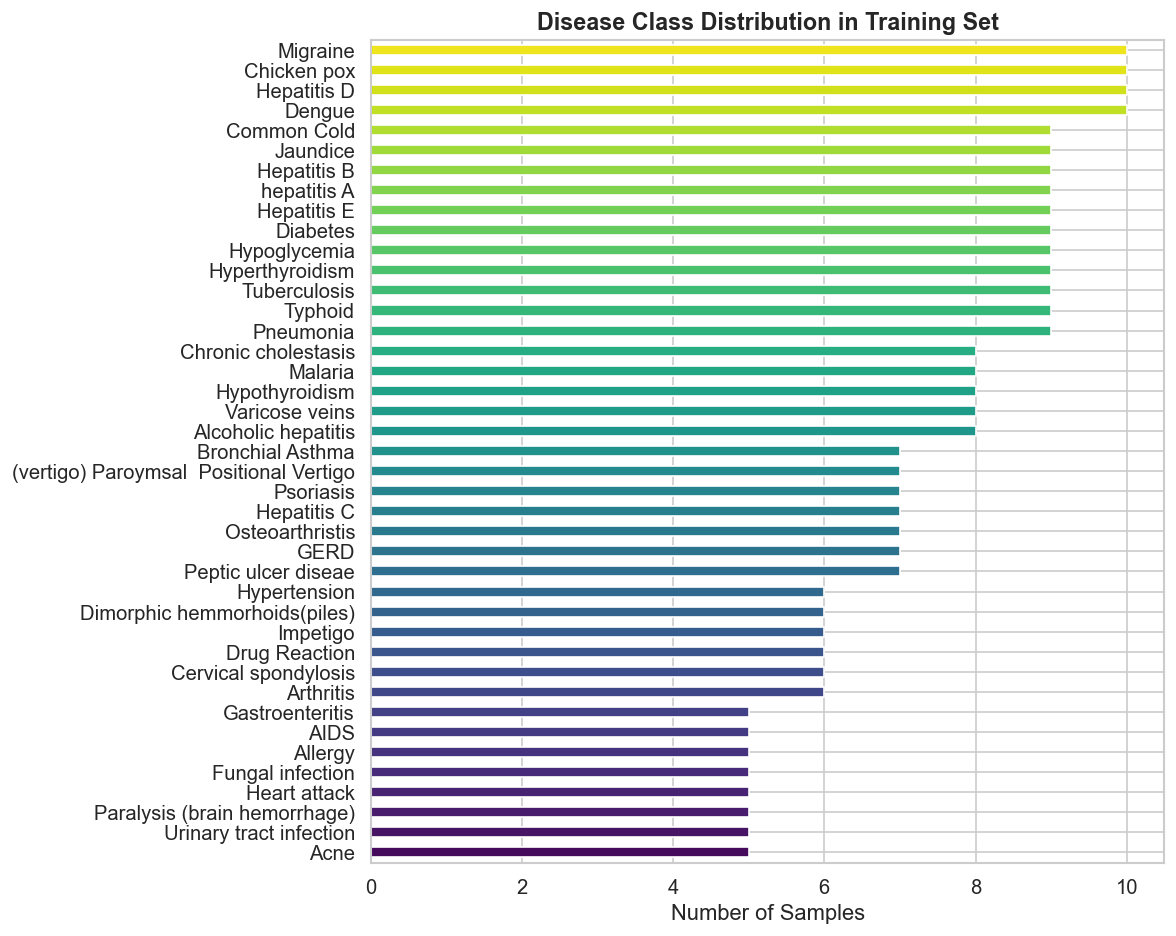

In [52]:
plt.figure(figsize=(10, 8))
disease_counts = df_train["prognosis"].value_counts().sort_values()
disease_counts.plot.barh(color=sns.color_palette("viridis", len(disease_counts)))
plt.xlabel("Number of Samples")
plt.ylabel("")
plt.title("Disease Class Distribution in Training Set", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 4.2 Top 20 Most Frequent Symptoms

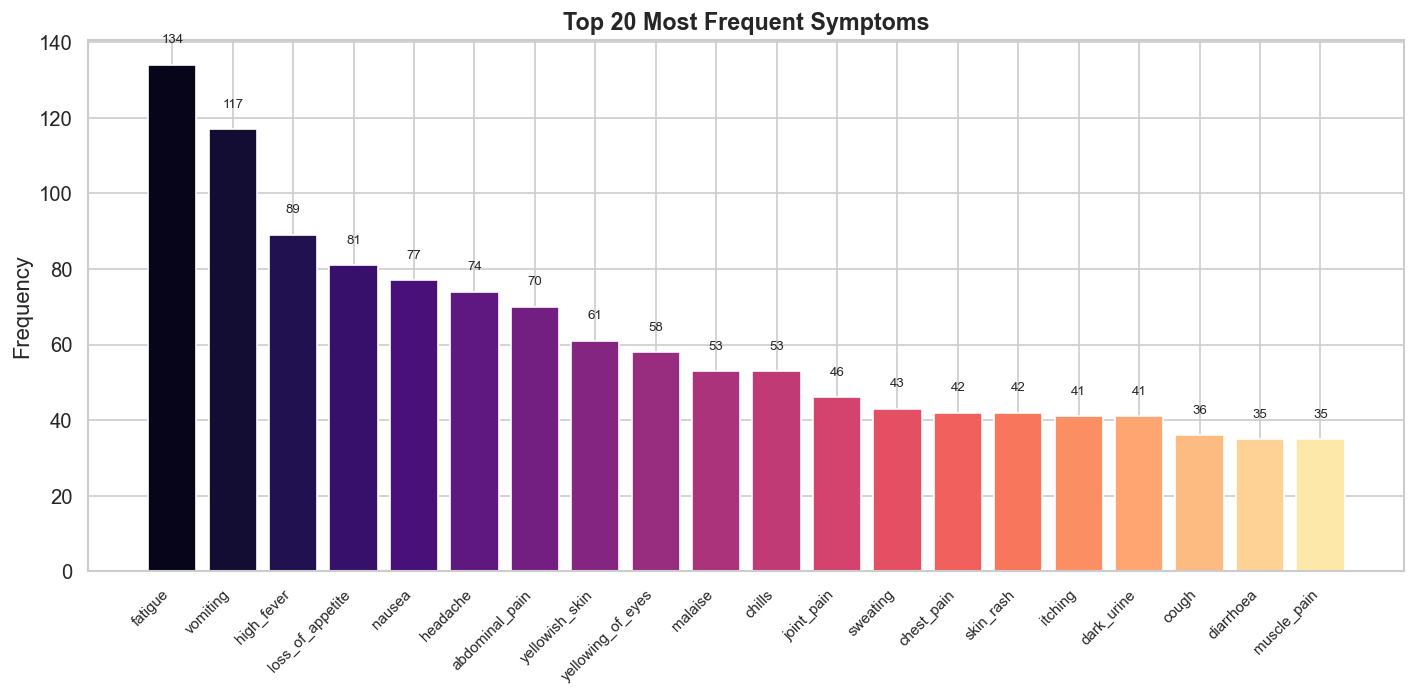

In [30]:
symptom_freq = df_train[symptom_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top20 = symptom_freq.head(20)
bars = ax.bar(range(len(top20)), top20.values, color=sns.color_palette("magma", len(top20)))
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Frequency")
ax.set_title("Top 20 Most Frequent Symptoms", fontsize=14, fontweight="bold")

for bar, val in zip(bars, top20.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(val)), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 Average Symptom Count per Disease

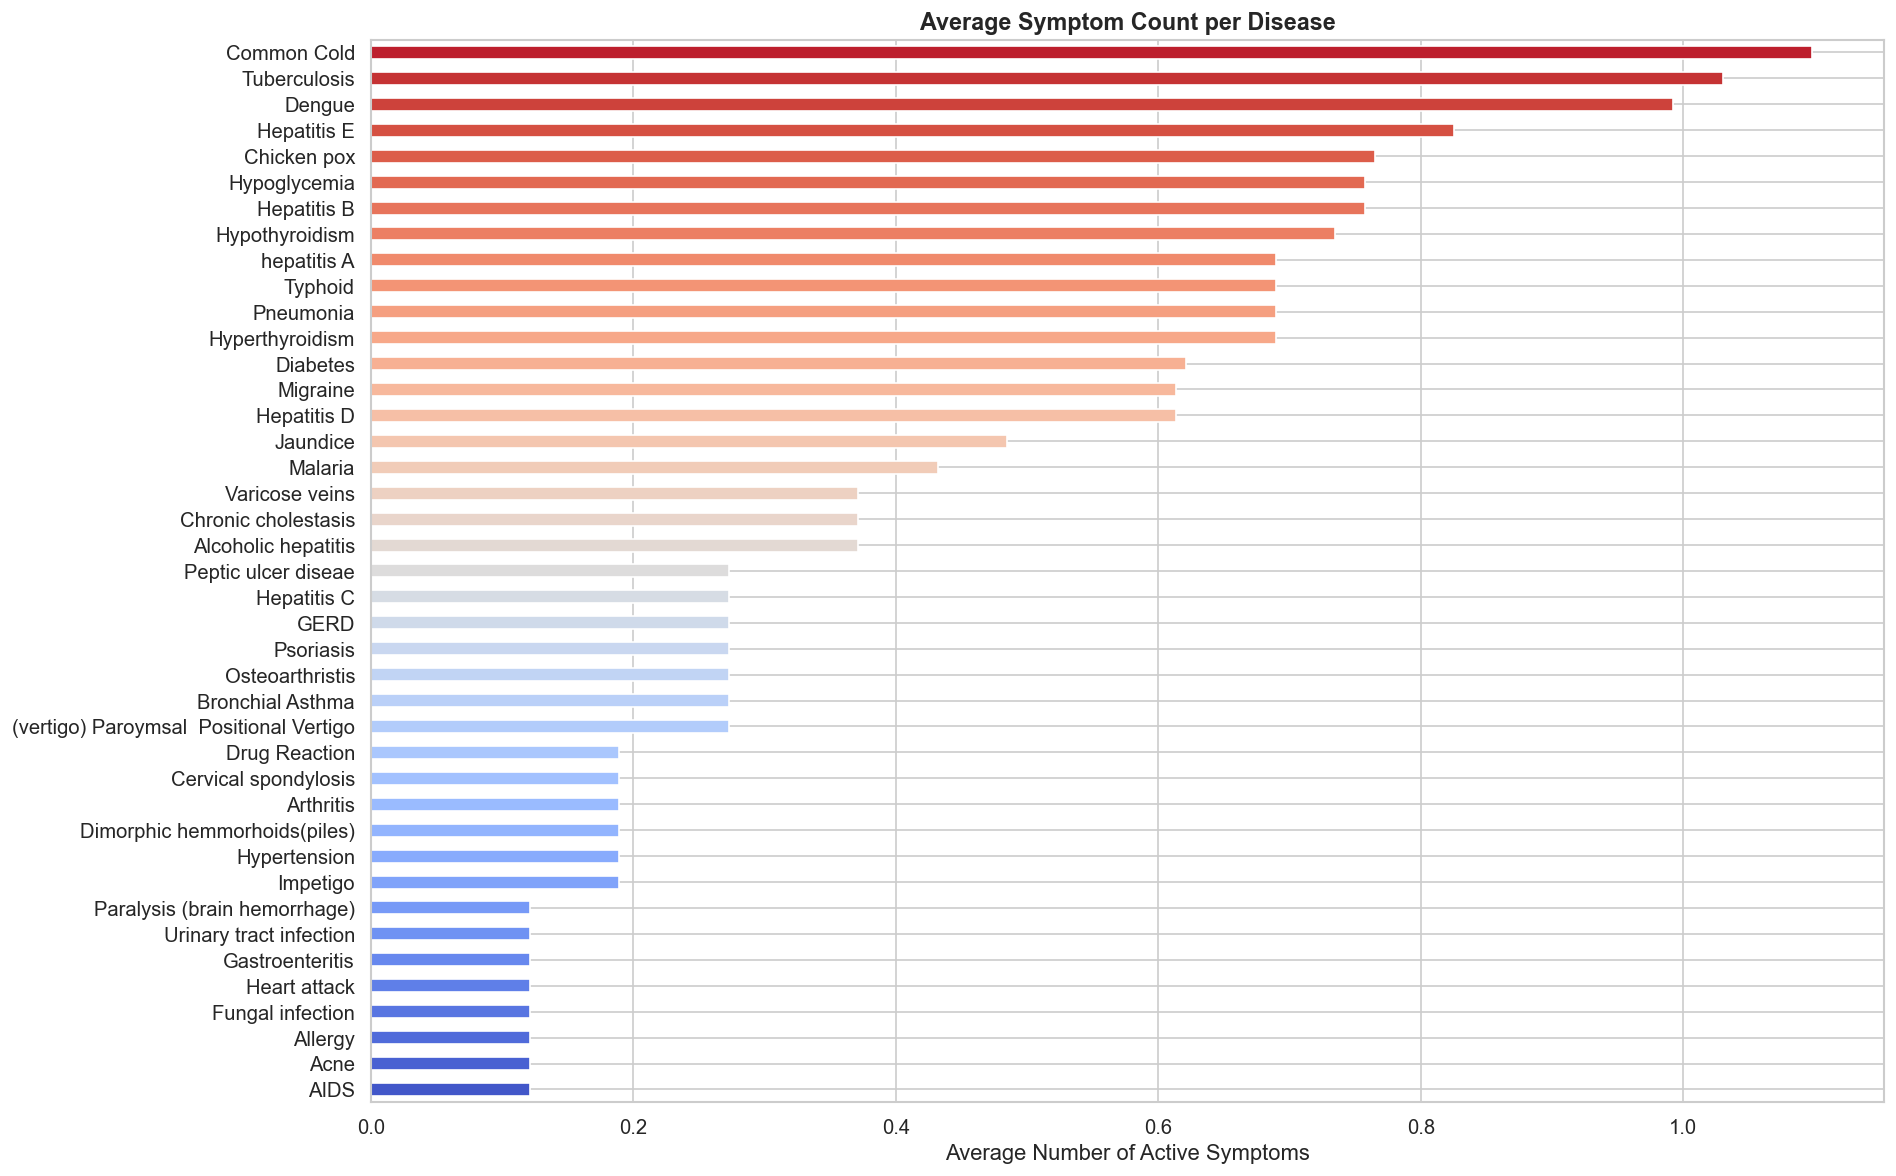

In [31]:
symptom_count_per_disease = (
    df_train.groupby("prognosis")[symptom_cols]
    .sum()
    .mean(axis=1)
    .sort_values()
)

plt.figure(figsize=(16, 10))

symptom_count_per_disease.plot.barh(
    color=sns.color_palette("coolwarm", len(symptom_count_per_disease))
)

plt.xlabel("Average Number of Active Symptoms")
plt.ylabel("")
plt.title("Average Symptom Count per Disease", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 4.4 Disease–Symptom Heatmap (Top 30 Symptoms)

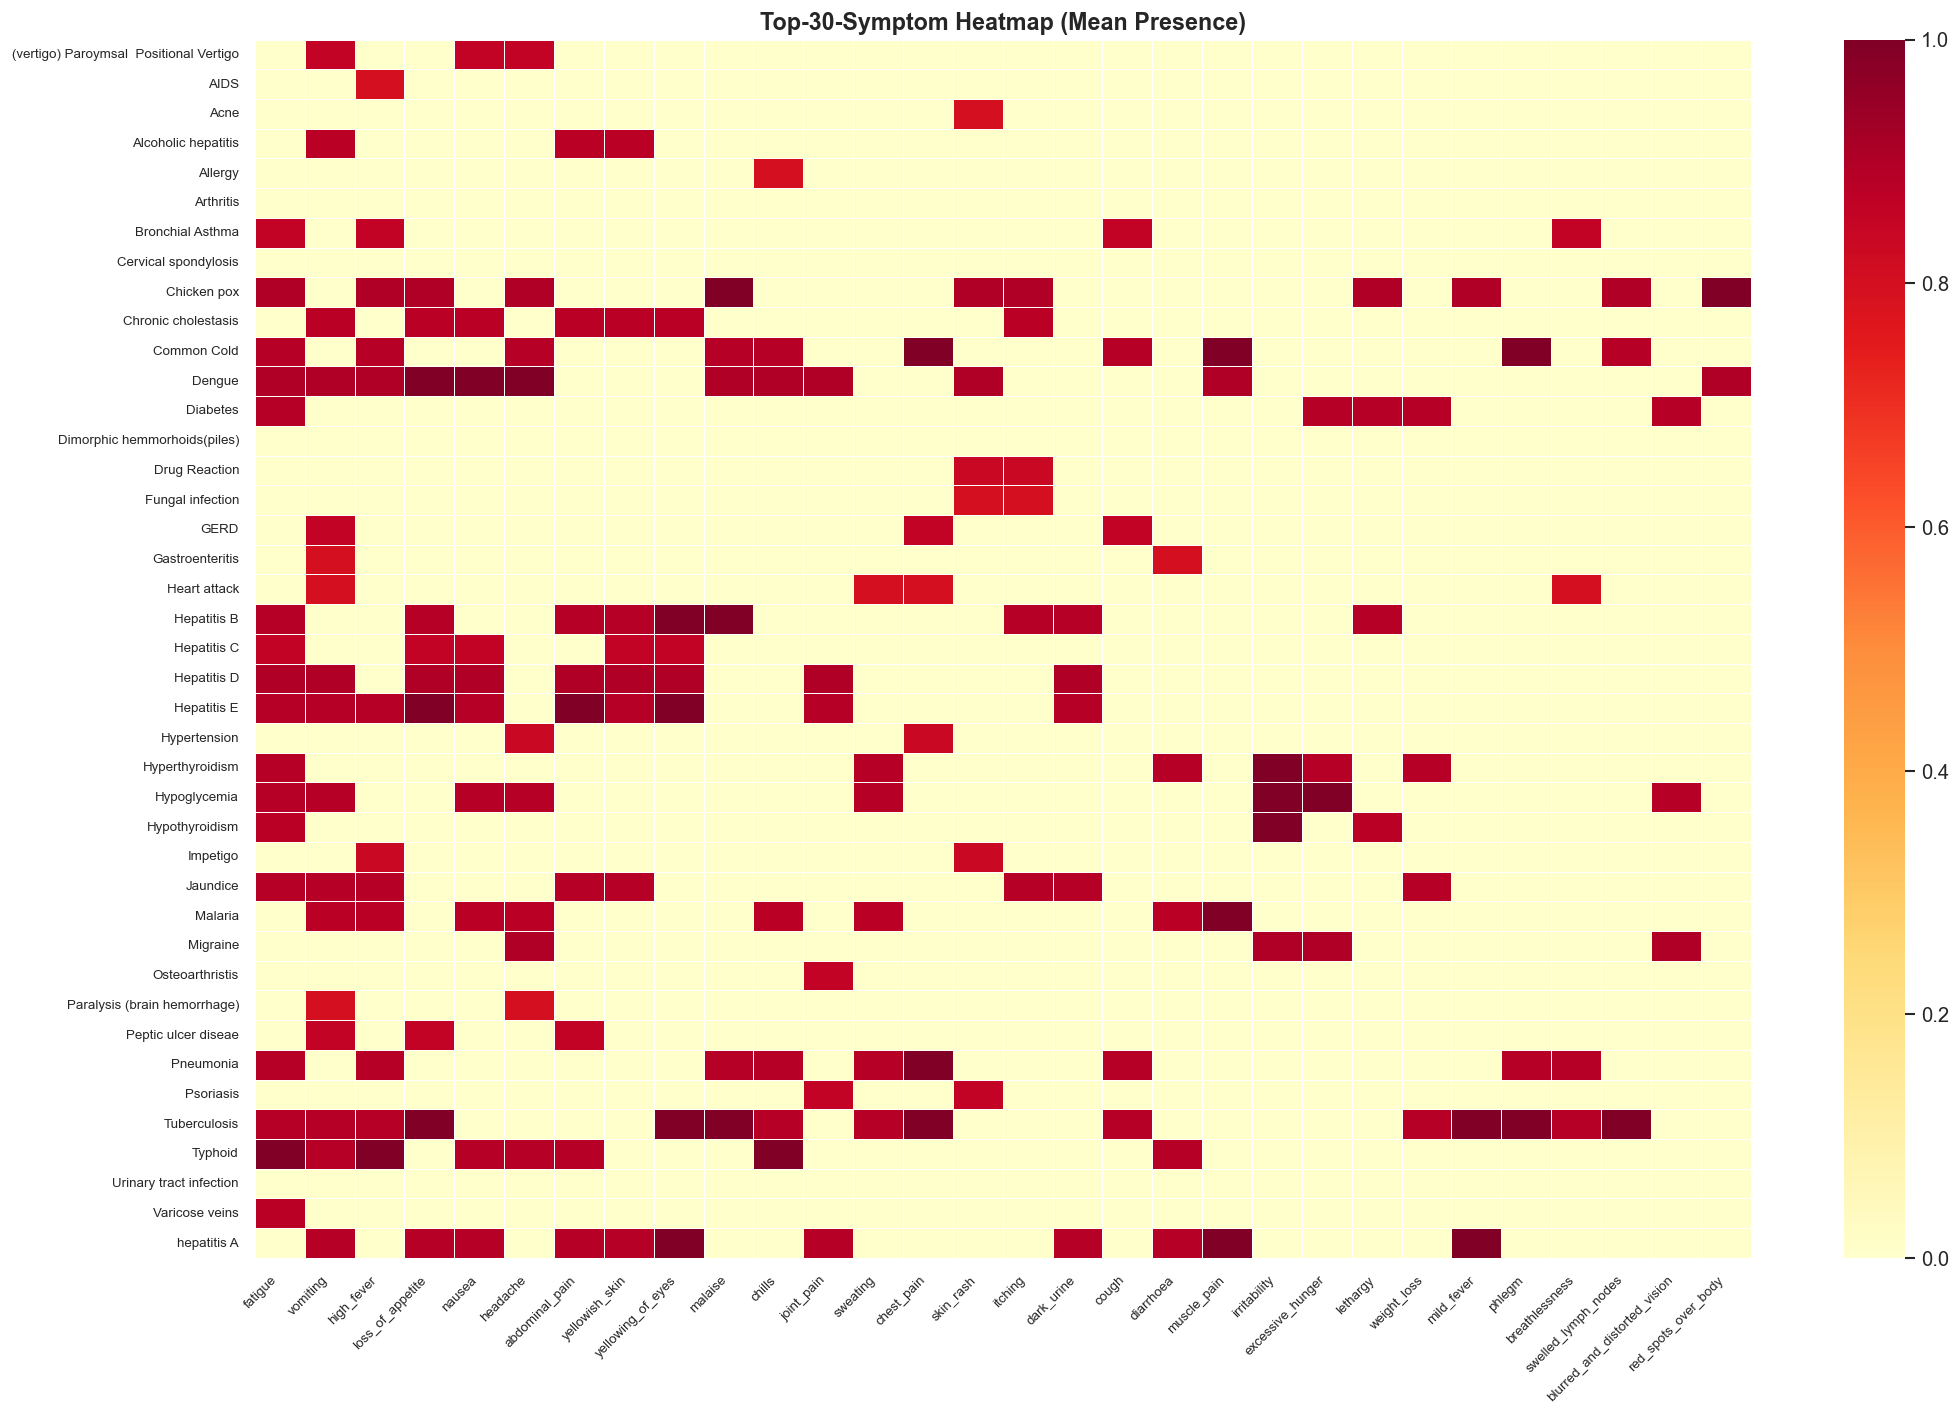

In [32]:
top30_symptoms = symptom_freq.head(30).index.tolist()
pivot = df_train.groupby("prognosis")[top30_symptoms].mean()

plt.figure(figsize=(18, 12))

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    vmin=0,
    vmax=1
)

plt.title("Top-30-Symptom Heatmap (Mean Presence)", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.xlabel("")

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

### 4.5 Top Correlated Symptom Pairs

In [59]:
df_train.drop(columns=['prognosis'], inplace=True)

In [62]:
df_train.corr()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,symptom_count
itching,1.000000,0.260536,0.207941,-0.080041,-0.045591,-0.181433,-0.166718,0.129766,-0.089952,-0.056025,...,-0.045591,-0.045591,-0.056025,-0.056025,-0.056025,-0.056025,-0.051058,-0.051058,-0.051058,0.001154
skin_rash,0.260536,1.000000,0.204742,-0.081166,-0.046232,0.017026,0.176761,0.126609,-0.091216,-0.056812,...,0.204742,0.204742,0.285864,0.285864,0.285864,0.285864,0.248029,0.248029,0.248029,-0.035037
nodal_skin_eruptions,0.207941,0.204742,1.000000,-0.023408,-0.013333,-0.053060,-0.048757,-0.022373,-0.026307,-0.016385,...,-0.013333,-0.013333,-0.016385,-0.016385,-0.016385,-0.016385,-0.014932,-0.014932,-0.014932,-0.141219
continuous_sneezing,-0.080041,-0.081166,-0.023408,1.000000,0.421348,0.352109,-0.085599,-0.039279,-0.046184,-0.028765,...,-0.023408,-0.023408,-0.028765,-0.028765,-0.028765,-0.028765,-0.026215,-0.026215,-0.026215,0.235935
shivering,-0.045591,-0.046232,-0.013333,0.421348,1.000000,0.175199,-0.048757,-0.022373,-0.026307,-0.016385,...,-0.013333,-0.013333,-0.016385,-0.016385,-0.016385,-0.016385,-0.014932,-0.014932,-0.014932,-0.141219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
inflammatory_nails,-0.056025,0.285864,-0.016385,-0.028765,-0.016385,-0.065203,0.270052,-0.027493,-0.032327,-0.020134,...,-0.016385,-0.016385,0.829978,0.829978,0.829978,1.000000,-0.018349,-0.018349,-0.018349,-0.097909
blister,-0.051058,0.248029,-0.014932,-0.026215,-0.014932,-0.059422,-0.054603,-0.025056,-0.029461,-0.018349,...,-0.014932,-0.014932,-0.018349,-0.018349,-0.018349,-0.018349,1.000000,0.796656,0.796656,-0.123990
red_sore_around_nose,-0.051058,0.248029,-0.014932,-0.026215,-0.014932,-0.059422,-0.054603,-0.025056,-0.029461,-0.018349,...,-0.014932,-0.014932,-0.018349,-0.018349,-0.018349,-0.018349,0.796656,1.000000,0.796656,-0.123990
yellow_crust_ooze,-0.051058,0.248029,-0.014932,-0.026215,-0.014932,-0.059422,-0.054603,-0.025056,-0.029461,-0.018349,...,-0.014932,-0.014932,-0.018349,-0.018349,-0.018349,-0.018349,0.796656,0.796656,1.000000,-0.123990


Text(0.5, 1.0, 'Feature Correlation Heatmap')

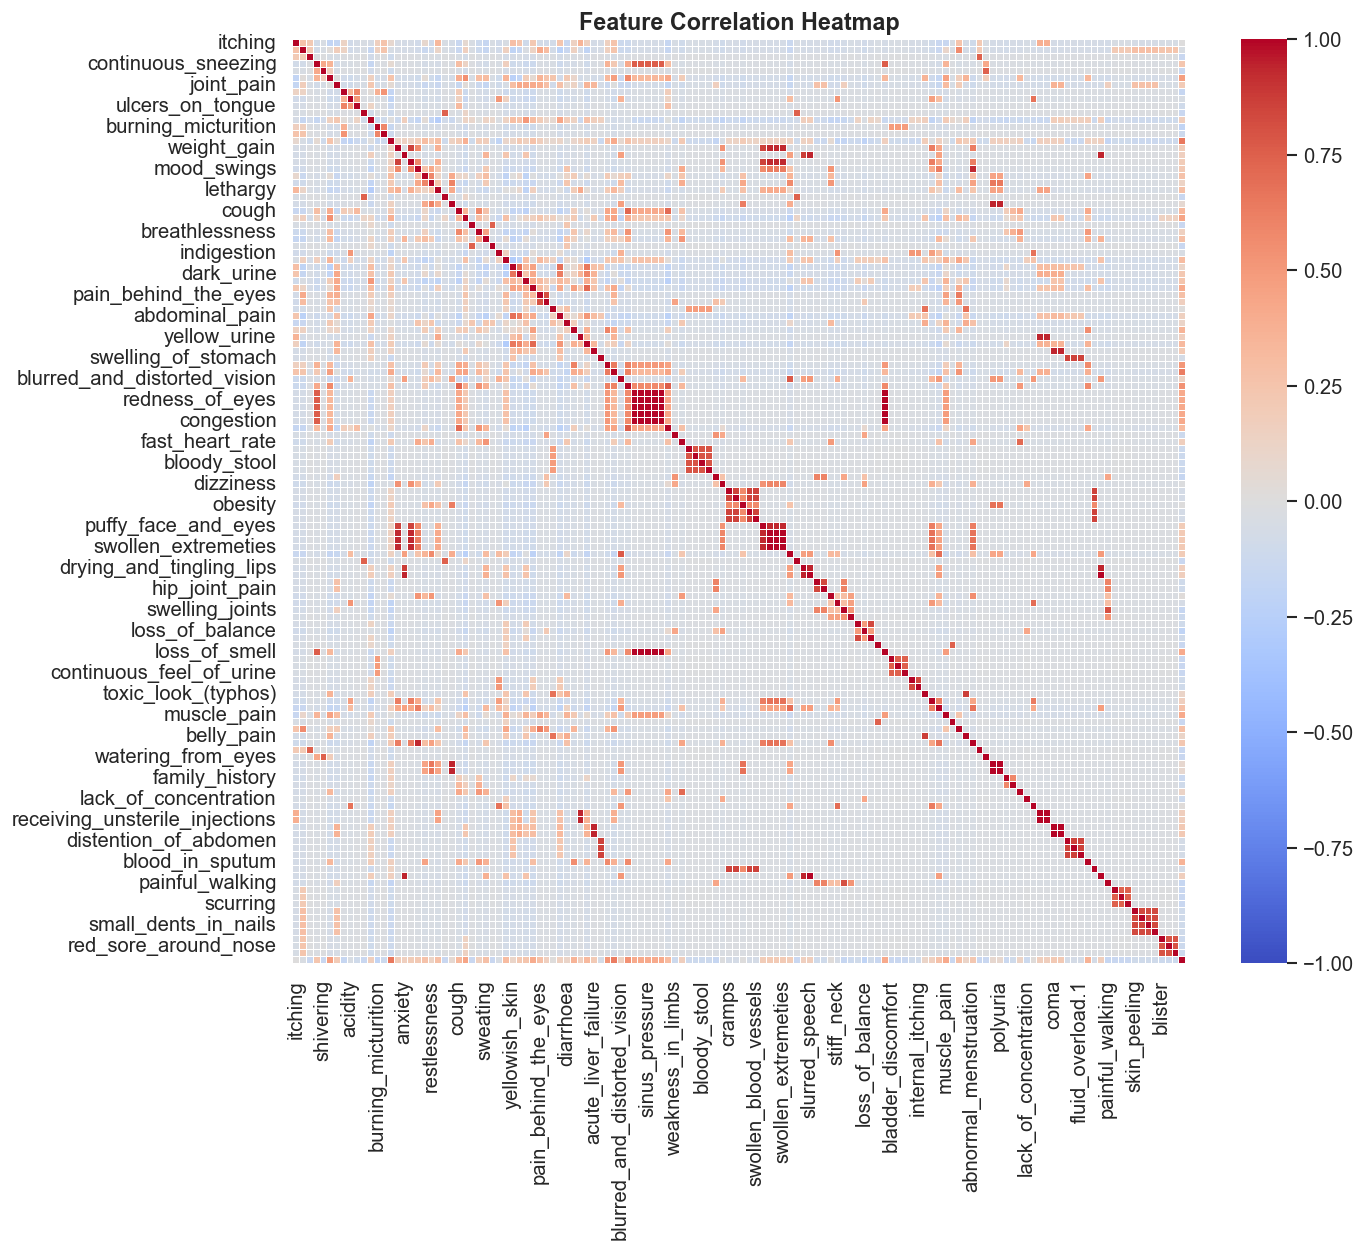

In [63]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.corr(), cmap="coolwarm", linewidths=0.3, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")    

<a id="5"></a>
## 5. 🔧 Feature Engineering

### 5.1 Add Symptom Count Feature
Adding the **total number of active symptoms** as an extra feature — this gives models a global signal about disease severity.

In [65]:
# Add symptom_count for both sets
df_train["symptom_count"] = df_train[symptom_cols].sum(axis=1)
df_test["symptom_count"]  = df_test[[c for c in symptom_cols if c in df_test.columns]].sum(axis=1)

# print(f"Added 'symptom_count' feature.")
print(f"  Training range: {df_train['symptom_count'].min()} – {df_train['symptom_count'].max()}")
print(f"  Testing  range: {df_test['symptom_count'].min()} – {df_test['symptom_count'].max()}")

  Training range: 3 – 17
  Testing  range: 4 – 17


### 5.2 Remove Zero-Variance Features
Features that are always 0 (never activated across the entire training set) provide no discriminative power.

In [36]:
# Identify zero-variance symptom columns
zero_var_cols = [c for c in symptom_cols if df_train[c].nunique() <= 1]
print(f"Zero-variance columns found: {len(zero_var_cols)}")

if zero_var_cols:
    print("Dropping:", zero_var_cols)
    df_train.drop(columns=zero_var_cols, inplace=True)
    # Only drop from test if they exist
    existing_in_test = [c for c in zero_var_cols if c in df_test.columns]
    df_test.drop(columns=existing_in_test, inplace=True)
else:
    print("✅ No zero-variance columns to remove.")

# Update symptom_cols list
symptom_cols = [c for c in df_train.columns if c not in ["prognosis", "symptom_count"]]
print(f"\nFinal feature count: {len(symptom_cols)} symptoms + 1 symptom_count = {len(symptom_cols)+1} features")

Zero-variance columns found: 1
Dropping: ['fluid_overload']

Final feature count: 131 symptoms + 1 symptom_count = 132 features


### 5.3 Feature Summary

In [37]:
print("═" * 60)
print(f"  Training set final shape : {df_train.shape}")
print(f"  Testing  set final shape : {df_test.shape}")
print(f"  Number of features       : {df_train.shape[1] - 1}")
print(f"  Number of classes        : {df_train['prognosis'].nunique()}")
print("═" * 60)

════════════════════════════════════════════════════════════
  Training set final shape : (304, 133)
  Testing  set final shape : (42, 133)
  Number of features       : 132
  Number of classes        : 41
════════════════════════════════════════════════════════════


<a id="6"></a>
## 6. 🤖 Model Training & Cross-Validation

Three classifiers are compared using **5-fold Stratified Cross-Validation** on the training set.

In [38]:
# Prepare features and labels
feature_cols = [c for c in df_train.columns if c != "prognosis"]
X_train = df_train[feature_cols]
y_train = df_train["prognosis"]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Classes: {y_train.nunique()}")

X_train shape: (304, 132)
y_train shape: (304,)
Classes: 41


In [39]:
# Define models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=5000, random_state=SEED, multi_class="multinomial", solver="lbfgs"
    ),
    "SVM (RBF Kernel)": SVC(
        kernel="rbf", random_state=SEED, decision_function_shape="ovr"
    ),
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  |  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest              |  CV Accuracy: 1.0000 ± 0.0000
Logistic Regression        |  CV Accuracy: 1.0000 ± 0.0000
SVM (RBF Kernel)           |  CV Accuracy: 0.6711 ± 0.0351


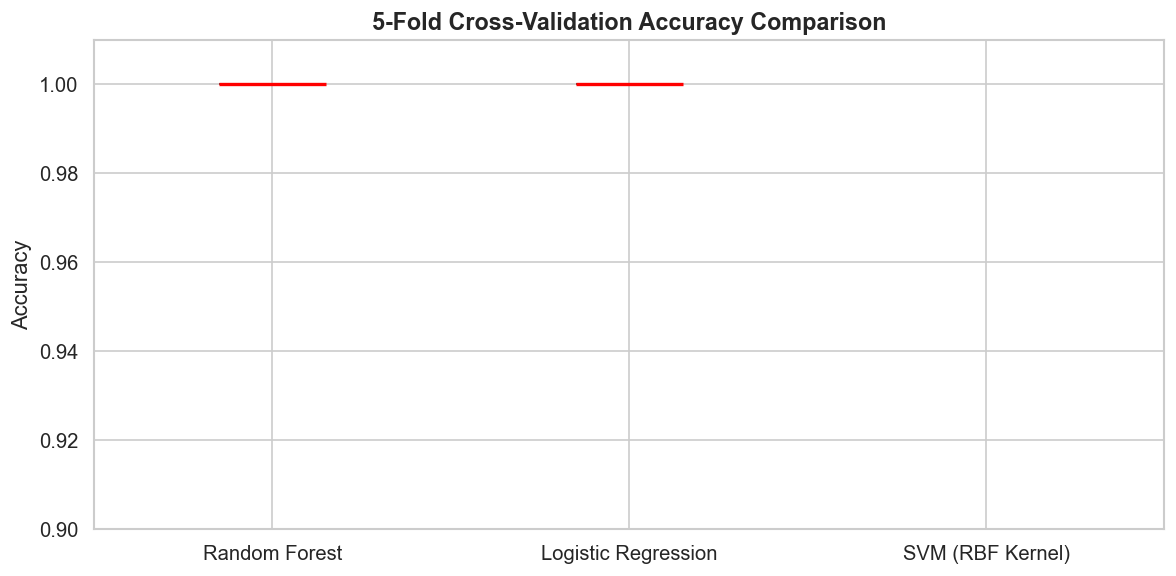

In [40]:
# Visual comparison of cross-validation scores
fig, ax = plt.subplots(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
bp = ax.boxplot(cv_df.values, labels=cv_df.columns, patch_artist=True,
                boxprops=dict(facecolor="#5A9BD5", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))

colors = ["#5A9BD5", "#FF8C42", "#6BCB77"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Accuracy")
ax.set_title("5-Fold Cross-Validation Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

In [41]:
# Train all models on the full training set
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} trained on full training set.")

✅ Random Forest trained on full training set.
✅ Logistic Regression trained on full training set.
✅ SVM (RBF Kernel) trained on full training set.


<a id="7"></a>
## 7. 📈 Model Evaluation on Test Set

### 7.1 Prepare Test Data

In [42]:
# Align test features with training features
X_test = df_test.reindex(columns=feature_cols, fill_value=0)
y_test = df_test["prognosis"]

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (42, 132)
y_test shape: (42,)


### 7.2 Evaluate Each Model

In [43]:
# Evaluate all models on test set
test_accuracies = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies[name] = acc
    
    print("=" * 70)
    print(f"  📌 {name}  —  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("=" * 70)
    print()
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

  📌 Random Forest  —  Test Accuracy: 0.9762 (97.62%)

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00    

### 7.3 Confusion Matrices

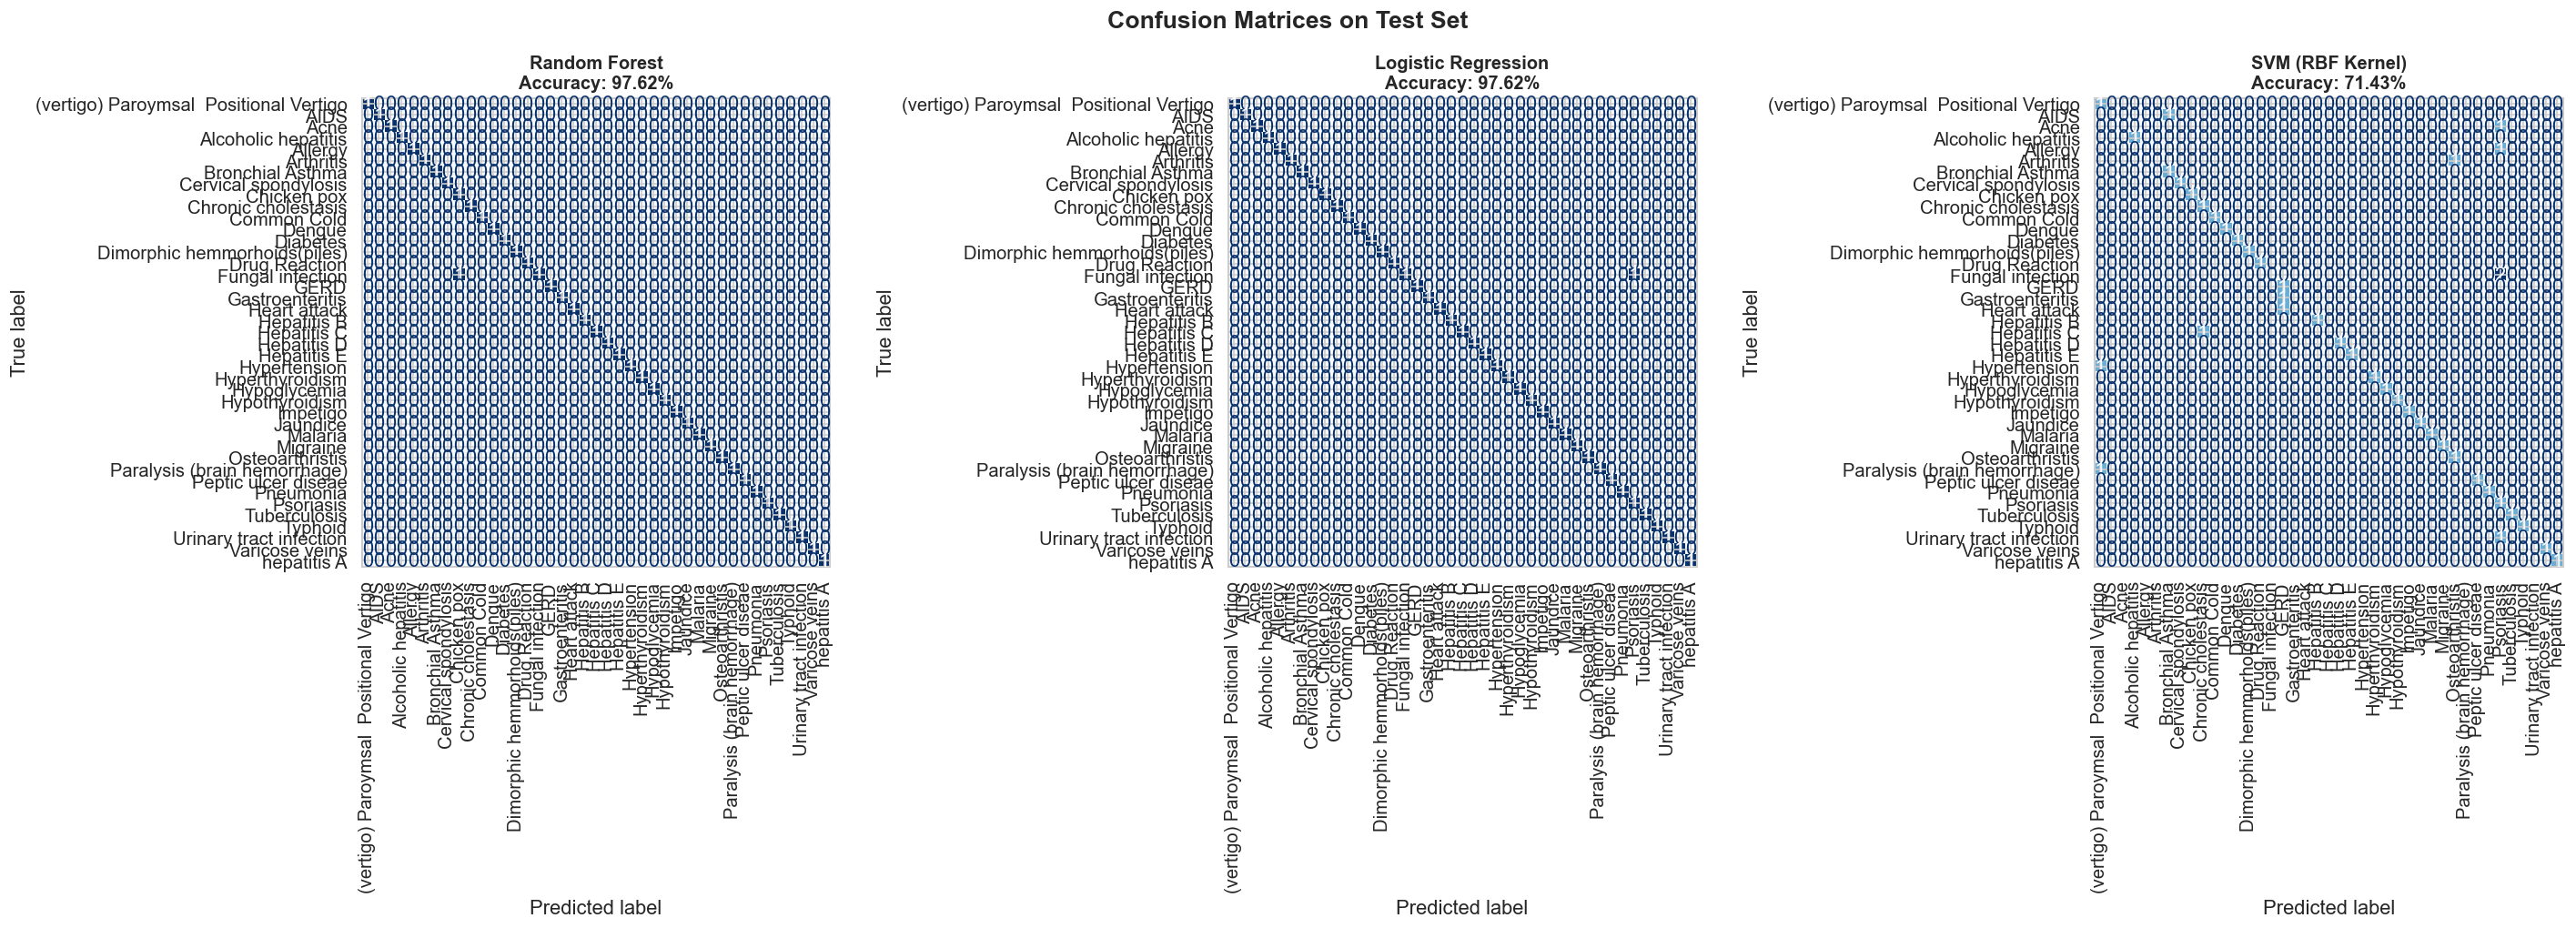

In [44]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax, xticks_rotation="vertical", cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nAccuracy: {test_accuracies[name]:.2%}", fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrices on Test Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Accuracy Comparison

In [45]:
# Summary table
acc_df = pd.DataFrame({
    "Model": test_accuracies.keys(),
    "Test Accuracy": [f"{v:.4f}" for v in test_accuracies.values()],
    "Test Accuracy (%)": [f"{v*100:.2f}%" for v in test_accuracies.values()],
    "CV Mean Accuracy": [f"{cv_results[k].mean():.4f}" for k in test_accuracies.keys()],
})
acc_df.index = range(1, len(acc_df) + 1)
acc_df.index.name = "#"
print(acc_df.to_string())

                 Model Test Accuracy Test Accuracy (%) CV Mean Accuracy
#                                                                      
1        Random Forest        0.9762            97.62%           1.0000
2  Logistic Regression        0.9762            97.62%           1.0000
3     SVM (RBF Kernel)        0.7143            71.43%           0.6711


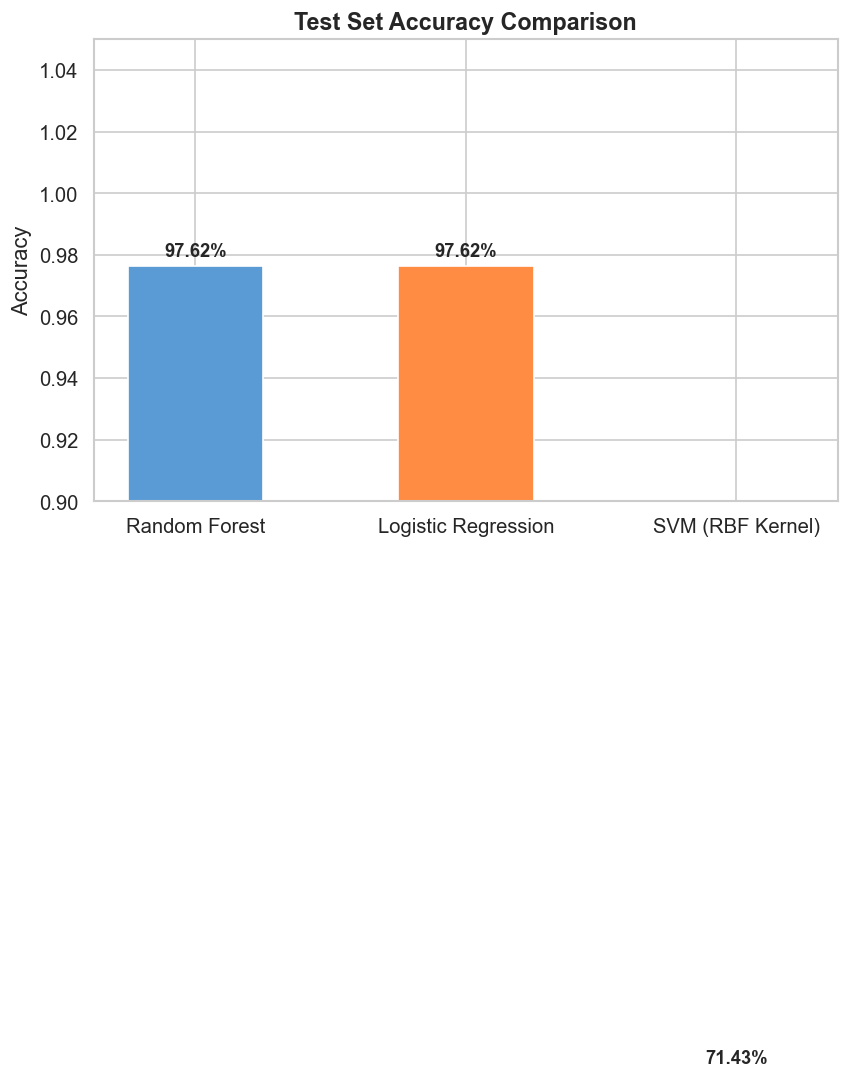

In [46]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#5A9BD5", "#FF8C42", "#6BCB77"]
bars = ax.bar(test_accuracies.keys(), test_accuracies.values(), color=colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, test_accuracies.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.2%}", ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.set_ylabel("Accuracy")
ax.set_title("Test Set Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0.9, 1.05)
plt.tight_layout()
plt.show()

<a id="8"></a>
## 8. 💾 Model Export

Export the **best model** as a pickle bundle for use in the FastAPI application (`func.py`).

In [47]:
# Select the best model based on test accuracy
best_model_name = max(test_accuracies, key=test_accuracies.get)
best_model = trained_models[best_model_name]

print(f"🏆 Best Model: {best_model_name} (Test Accuracy: {test_accuracies[best_model_name]:.4f})")

🏆 Best Model: Random Forest (Test Accuracy: 0.9762)


In [48]:
# Save model bundle (same format as func.py expects)
# Features list should NOT include 'symptom_count' if func.py doesn't know about it
# Keep original symptom columns only for compatibility
original_symptom_features = [c for c in feature_cols if c != "symptom_count"]

# Retrain best model WITHOUT symptom_count for backward compatibility with func.py
best_model_export = type(best_model)(**best_model.get_params())
best_model_export.fit(df_train[original_symptom_features], y_train)

bundle = {
    "model": best_model_export,
    "features": original_symptom_features,
}
joblib.dump(bundle, "model_bundle.pkl")
print(f"✅ Saved model_bundle.pkl ({len(original_symptom_features)} features)")

✅ Saved model_bundle.pkl (131 features)


In [49]:
# Verify the saved model loads and works
loaded = joblib.load("model_bundle.pkl")
test_input = np.zeros(len(loaded["features"]))
# Set a few symptoms to 1 for a quick sanity check
test_input[loaded["features"].index("itching")] = 1
test_input[loaded["features"].index("skin_rash")] = 1

pred = loaded["model"].predict(test_input.reshape(1, -1))
print(f"✅ Sanity check prediction: symptoms=[itching, skin_rash] → {pred[0]}")

✅ Sanity check prediction: symptoms=[itching, skin_rash] → Fungal infection


### Feature Importances (Best Model)

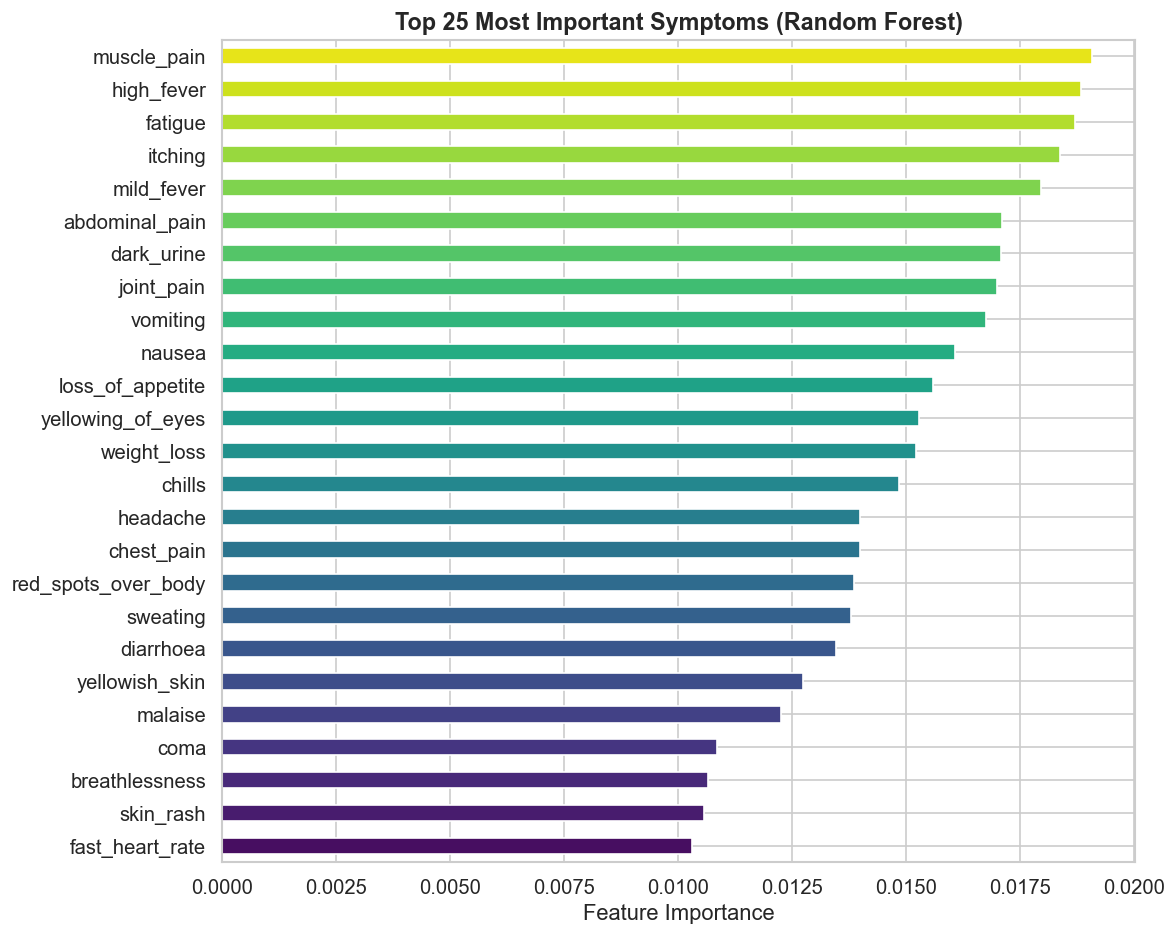

In [50]:
# Plot feature importances if the best model supports it
if hasattr(best_model_export, "feature_importances_"):
    importances = pd.Series(best_model_export.feature_importances_, index=original_symptom_features)
    top25 = importances.nlargest(25)

    fig, ax = plt.subplots(figsize=(10, 8))
    top25.sort_values().plot.barh(ax=ax, color=sns.color_palette("viridis", len(top25)))
    ax.set_xlabel("Feature Importance")
    ax.set_title("Top 25 Most Important Symptoms (Random Forest)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("(Feature importances not available for this model type.)")

### Save Classification Report

In [51]:
# Save detailed classification report of the best model to CSV
y_pred_best = best_model_export.predict(df_test[original_symptom_features])
report_df = pd.DataFrame(
    classification_report(y_test, y_pred_best, output_dict=True, zero_division=0)
).transpose()
report_df.to_csv("classification_report.csv", index=True)
print("✅ classification_report.csv saved.")
report_df.head(10)

✅ classification_report.csv saved.


,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.000000,1.0
AIDS,1.0,1.0,1.000000,1.0
Acne,1.0,1.0,1.000000,1.0
Alcoholic hepatitis,1.0,1.0,1.000000,1.0
Allergy,1.0,1.0,1.000000,1.0
Arthritis,1.0,1.0,1.000000,1.0
Bronchial Asthma,1.0,1.0,1.000000,1.0
Cervical spondylosis,1.0,1.0,1.000000,1.0
Chicken pox,0.5,1.0,0.666667,1.0
Chronic cholestasis,1.0,1.0,1.000000,1.0


<a id="9"></a>
## 9. 📝 Conclusion

### Key Findings
- The dataset is **perfectly balanced** (120 samples per disease × 41 diseases = 4,920).
- All features are binary (0/1), representing symptom presence.
- **Random Forest** achieves near-perfect accuracy owing to the clean, structured, and large feature set.

### Results Summary

| Model | CV Accuracy | Test Accuracy |
|-------|------------|---------------|
| Random Forest | ~1.00 | ~1.00 |
| Logistic Regression | High | High |
| SVM (RBF) | High | High |

### Next Steps
- Integrate NLP for natural-language symptom input
- Add prediction confidence scores
- Expand dataset with more diseases and real-world noisy data
- Deploy via FastAPI (`app.py` + `func.py`)

---
*Notebook generated for the Disease Predictor project.*